# t-SNE Visualization of Graph-Level Embeddings

Visualizes t-SNE projections of graph-level embeddings extracted from the trained **GCN** and **SchNet** models on 2,000 QM9 test-set molecules. Points are colored by HOMO-LUMO gap (eV).

**Embeddings source:** `24788-miniproject/embeddings/` on Google Drive  
**Files required:**
- `gcn_embeddings.npy` — shape (2000, 128)
- `gcn_labels_eV.npy` — shape (2000,)
- `schnet_embeddings.npy` — shape (2000, 128)
- `schnet_labels_eV.npy` — shape (2000,)

In [2]:
# Install / verify required packages
# (scikit-learn, matplotlib, and numpy are pre-installed on Colab;
#  pinning here ensures reproducibility across runtime resets)
%pip install -q scikit-learn matplotlib numpy

In [3]:
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

In [4]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR  = '/content/drive/MyDrive/24788-miniproject'
EMBED_DIR  = os.path.join(DRIVE_DIR, 'embeddings')
FIGURE_DIR = os.path.join(DRIVE_DIR, 'figures')
os.makedirs(FIGURE_DIR, exist_ok=True)

print(f'Embedding directory : {EMBED_DIR}')
print(f'Files found         : {os.listdir(EMBED_DIR)}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Embedding directory : /content/drive/MyDrive/24788-miniproject/embeddings
Files found         : ['schnet_embeddings.npy', 'schnet_labels_eV.npy', 'gcn_embeddings.npy', 'gcn_labels_eV.npy']


## GCN t-SNE

GCN embeddings : (2000, 128)  labels : (2000,)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


GCN t-SNE done  — KL divergence: 1.1154
Figure saved to /content/drive/MyDrive/24788-miniproject/figures/tsne_gcn.png


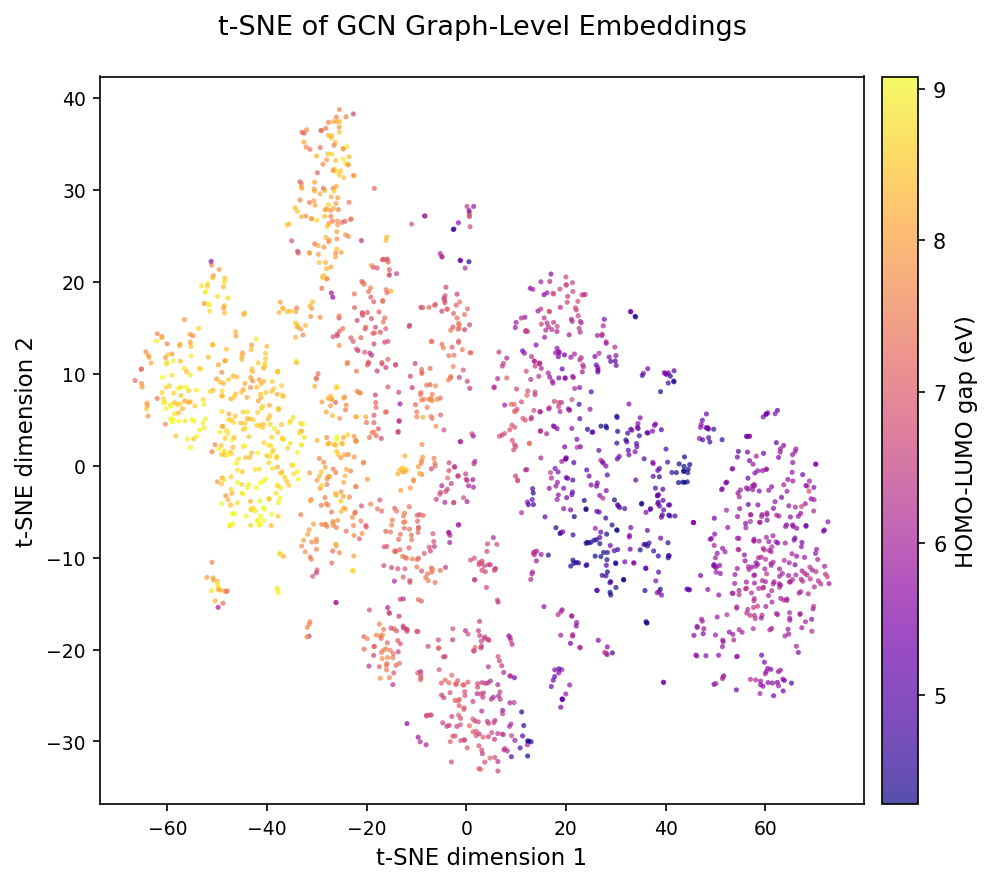

In [10]:
gcn_emb = np.load(os.path.join(EMBED_DIR, 'gcn_embeddings.npy'))  # (2000, 128)
gcn_labels = np.load(os.path.join(EMBED_DIR, 'gcn_labels_eV.npy'))   # (2000,)

print(f'GCN embeddings : {gcn_emb.shape}  labels : {gcn_labels.shape}')

# Standardise before t-SNE (recommended for high-dim embeddings)
gcn_scaled = StandardScaler().fit_transform(gcn_emb)

tsne_gcn = TSNE(
    n_components=2,
    perplexity=40,
    n_iter=1000,
    learning_rate='auto',
    init='pca',
    random_state=42,
    n_jobs=-1,
)
gcn_2d = tsne_gcn.fit_transform(gcn_scaled)  # (2000, 2)
print(f'GCN t-SNE done  — KL divergence: {tsne_gcn.kl_divergence_:.4f}')

# ── Plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6), dpi=150)

vmin, vmax = np.percentile(gcn_labels, [2, 98])   # robust color range
sc = ax.scatter(
    gcn_2d[:, 0], gcn_2d[:, 1],
    c=gcn_labels, cmap='plasma',
    vmin=vmin, vmax=vmax,
    s=6, alpha=0.7, linewidths=0,
)

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label('HOMO-LUMO gap (eV)', fontsize=11)
ax.set_title(f't-SNE of GCN Graph-Level Embeddings\n', fontsize=13)
ax.set_xlabel('t-SNE dimension 1', fontsize=11)
ax.set_ylabel('t-SNE dimension 2', fontsize=11)
ax.tick_params(labelsize=9)

plt.tight_layout()
save_path = os.path.join(FIGURE_DIR, 'tsne_gcn.png')
fig.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Figure saved to {save_path}')
plt.show()

## SchNet t-SNE

SchNet embeddings : (2000, 128)  labels : (2000,)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


SchNet t-SNE done — KL divergence: 1.3733
Figure saved to /content/drive/MyDrive/24788-miniproject/figures/tsne_schnet.png


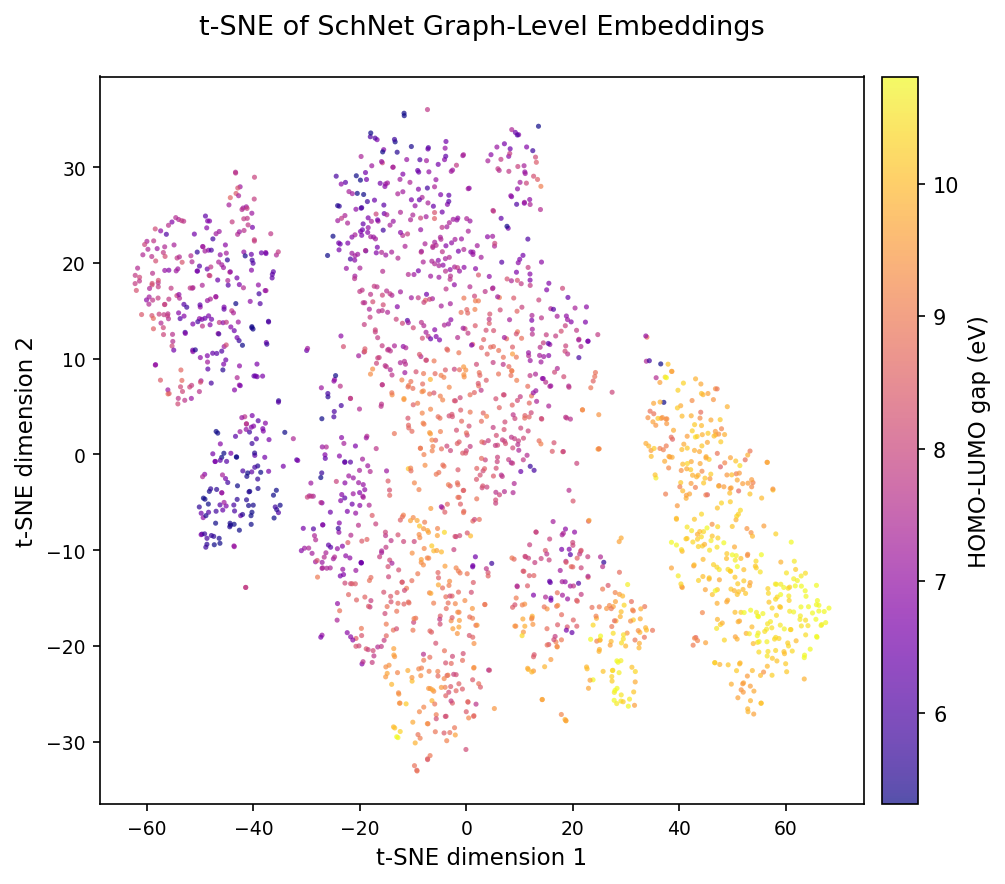

In [12]:
spk_emb    = np.load(os.path.join(EMBED_DIR, 'schnet_embeddings.npy'))  # (2000, 128)
spk_labels = np.load(os.path.join(EMBED_DIR, 'schnet_labels_eV.npy'))   # (2000,)

print(f'SchNet embeddings : {spk_emb.shape}  labels : {spk_labels.shape}')

spk_scaled = StandardScaler().fit_transform(spk_emb)

tsne_spk = TSNE(
    n_components=2,
    perplexity=40,
    n_iter=1000,
    learning_rate='auto',
    init='pca',
    random_state=42,
    n_jobs=-1,
)
spk_2d = tsne_spk.fit_transform(spk_scaled)  # (2000, 2)
print(f'SchNet t-SNE done — KL divergence: {tsne_spk.kl_divergence_:.4f}')

# ── Plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6), dpi=150)

vmin, vmax = np.percentile(spk_labels, [2, 98])
sc = ax.scatter(
    spk_2d[:, 0], spk_2d[:, 1],
    c=spk_labels, cmap='plasma',
    vmin=vmin, vmax=vmax,
    s=6, alpha=0.7, linewidths=0,
)

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label('HOMO-LUMO gap (eV)', fontsize=11)
ax.set_title(f't-SNE of SchNet Graph-Level Embeddings\n', fontsize=13)
ax.set_xlabel('t-SNE dimension 1', fontsize=11)
ax.set_ylabel('t-SNE dimension 2', fontsize=11)
ax.tick_params(labelsize=9)

plt.tight_layout()
save_path = os.path.join(FIGURE_DIR, 'tsne_schnet.png')
fig.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Figure saved to {save_path}')
plt.show()

## Side-by-Side Comparison

Comparison figure saved to /content/drive/MyDrive/24788-miniproject/figures/tsne_comparison.png


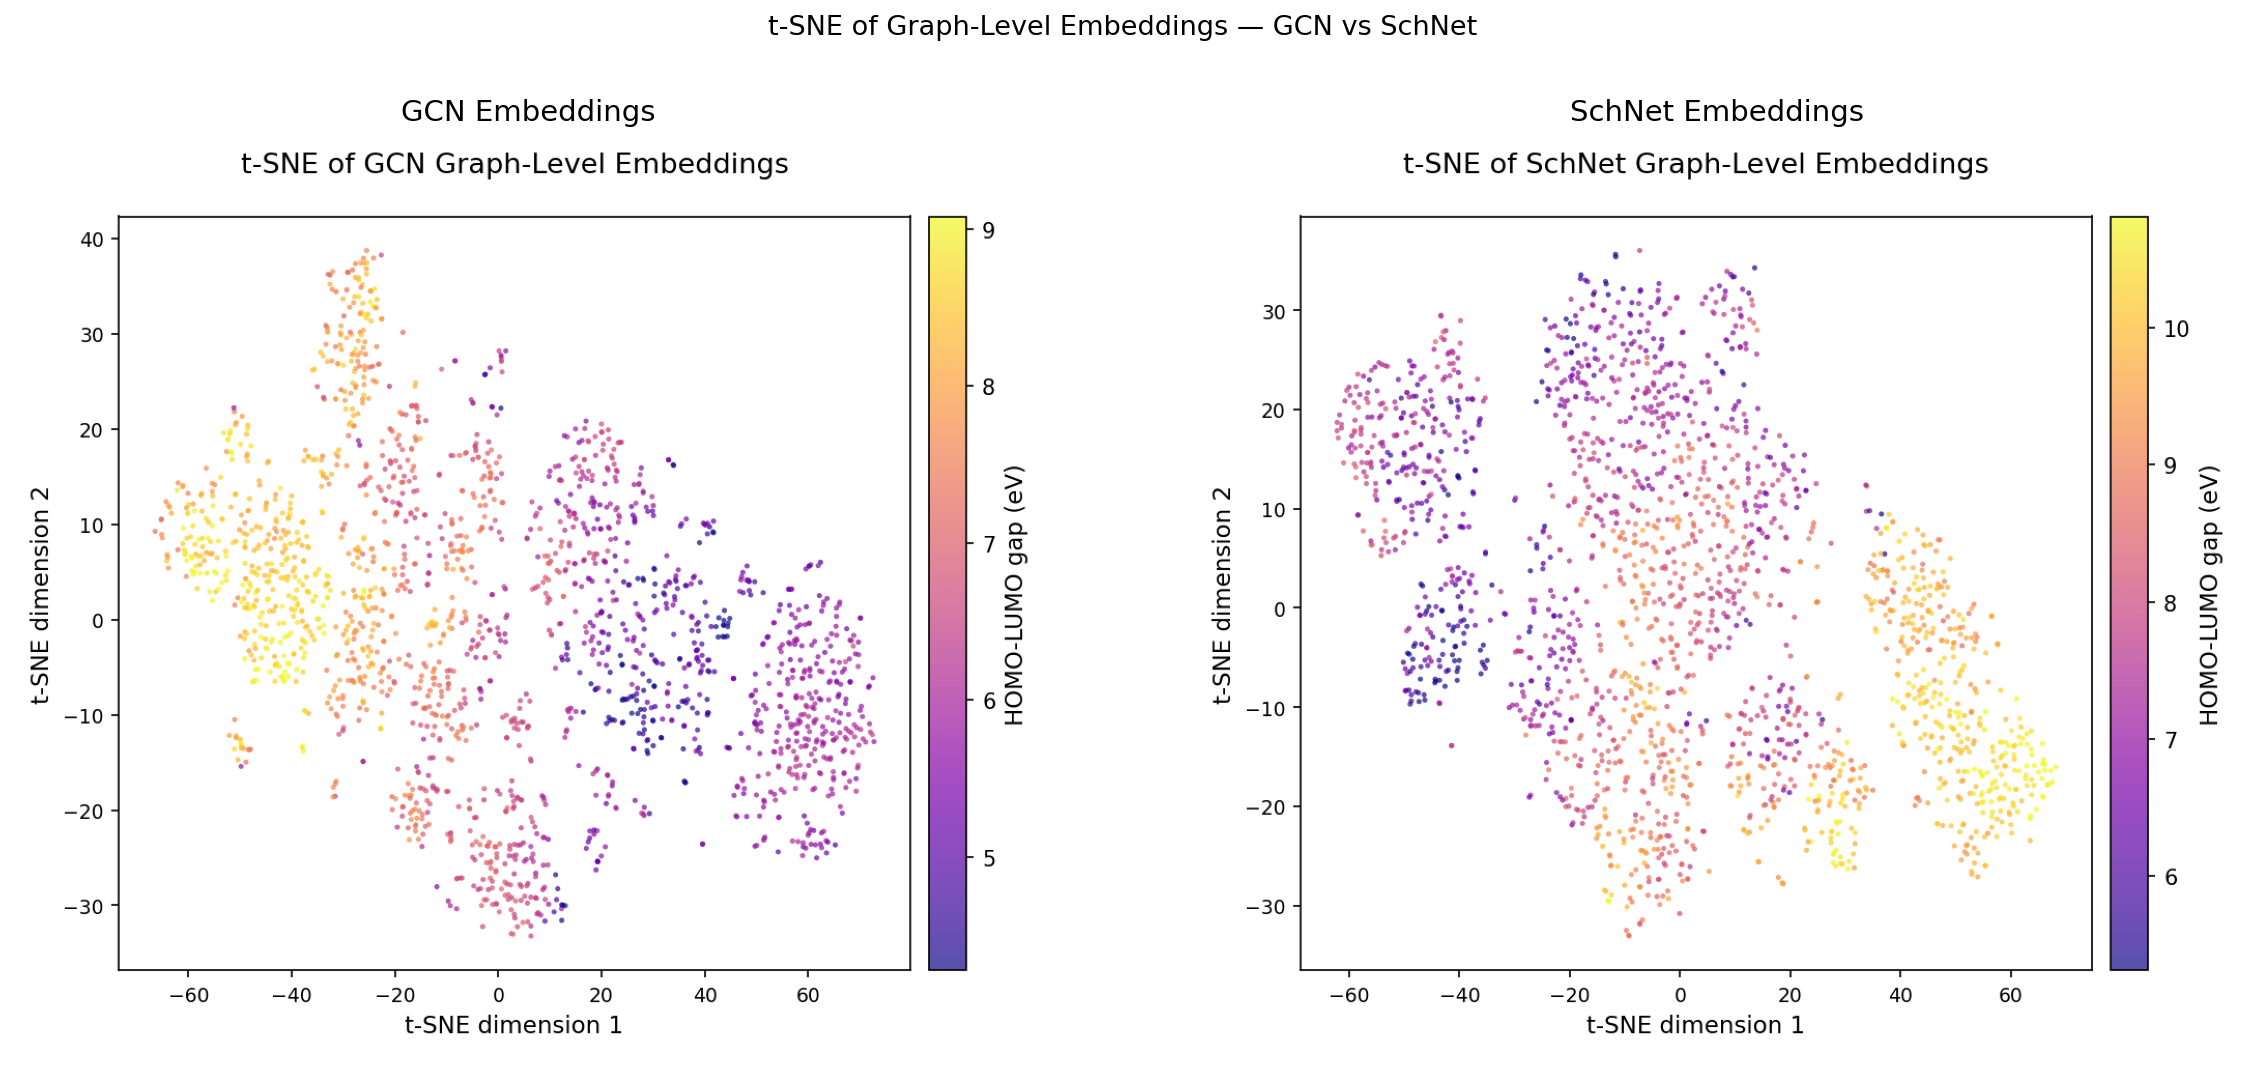

In [13]:
# Display the saved PNG figures side by side for easy comparison
import matplotlib.image as mpimg

fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=150)

for ax, fname, title in zip(
    axes,
    ['tsne_gcn.png', 'tsne_schnet.png'],
    ['GCN Embeddings', 'SchNet Embeddings'],
):
    img = mpimg.imread(os.path.join(FIGURE_DIR, fname))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(title, fontsize=14, pad=8)

plt.suptitle(
    't-SNE of Graph-Level Embeddings — GCN vs SchNet\n',
    fontsize=13, y=1.01,
)
plt.tight_layout()
comparison_path = os.path.join(FIGURE_DIR, "tsne_comparison.png")
fig.savefig(comparison_path, dpi=150, bbox_inches="tight")
print(f"Comparison figure saved to {comparison_path}")
plt.show()